# Six-Face Test: Calibration

Use this notebook to compute the calibration parameters with the data from the stationary captures.

## Setup

In [20]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import numpy as np
import matplotlib.pyplot as plt

G = 9.80665

reader = IMUSampleReader()
stationaryCaptures = [
    "../0-capture/stationary/may-2026/pos-x-up.csv",
    "../0-capture/stationary/may-2026/neg-x-up.csv",
    "../0-capture/stationary/may-2026/pos-y-up.csv",
    "../0-capture/stationary/may-2026/neg-y-up.csv",
    "../0-capture/stationary/may-2026/pos-z-up.csv",
    "../0-capture/stationary/may-2026/neg-z-up.csv",
]
rawOrientations = [reader.readRaw(file) for file in stationaryCaptures]

simpleRotationsCaptures = [
    "../0-capture/simple-rotations/jun-2026/rot-x-hw.csv",
    "../0-capture/simple-rotations/jun-2026/rot-y-hw.csv",
    "../0-capture/simple-rotations/jun-2026/rot-z-hw.csv",
]

realExerciseCaptures = [
    "../0-capture/real-exercises/apr-28-2026/dips-1.csv",
    "../0-capture/real-exercises/apr-28-2026/dips-2.csv",
    "../0-capture/real-exercises/apr-28-2026/dips-3.csv",
    "../0-capture/real-exercises/apr-28-2026/pull-ups-1.csv",
    "../0-capture/real-exercises/apr-28-2026/pull-ups-2.csv",
    "../0-capture/real-exercises/apr-28-2026/pull-ups-3.csv",
    "../0-capture/real-exercises/apr-28-2026/90-deg-push-ups-1.csv",
    "../0-capture/real-exercises/apr-28-2026/90-deg-push-ups-2.csv",
]

writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(stationaryCaptures)

Acceleration norms:	Mean = 9.890416
	Stdev = 0.251631
	Stationary tol = 1.258153
Gyroscope norms: 	Stdev = 2.328577
	Stationary tol = 6.985731


## Accelerometer 

TODO: Study residual acceleration after calibration

View accelerometer calibration as an affine transformation (rotation, shear, scaling, translation) applied to the raw sensor data to obtain the true physical values. Consider the linear system:

$$
\mathbf{A} \mathbf{x} = \mathbf{b} \\
 \mathbf{x} = (\mathbf{A}^t \mathbf{A})^{-1} \mathbf{A}^t \mathbf{b}
$$

Where:
- $\mathbf{A}$: the mean of raw sensor readings in the six static orientations. This is valid since standard deviations are tight overall, as seen in `1-analysis.ipynb`.
- $\mathbf{b}$: true physical values ($0$ or $\pm g$, depending on the axis and orientation).
- $\mathbf{x}$: transformation matrix obtained with least squares. 

Alternatives:
- Just substracting the bias (mean of each axis across all orientations) from the raw data. Too simple and maybe error prone.
- Using the current approach with many linear transformations for at least two known temperatures and use interpolation to get the parameters for any temperature. Feasible since the IMU measures temperature too, I can craft another device for temperature measurement with my Arduino Uno and a DHT11 sensor and can use a heater from home. Much more work and maybe the difference is not significant enough to justify it.
- Using some non-linear transformation. More precise but much more complex.

Sources: 
- https://cookierobotics.com/061/
- Linear Algebra - Stanley Grossman: 6.2. Approximation by Least Squares

In [ ]:
A = np.ones((len(stationaryCaptures), 4))
for i, (seq, a, w) in enumerate(rawOrientations):
    ax = np.mean(a[:, 0])
    ay = np.mean(a[:, 1])
    az = np.mean(a[:, 2])

    # 1: independent term for bias
    A[i] = [ax, ay, az, 1]
print(f"A = {A}")

b = np.zeros((len(stationaryCaptures), 3))
b[0][0] = G
b[1][0] = -G
b[2][1] = G
b[3][1] = -G
b[4][2] = G
b[5][2] = -G
print(f"\nb = {b}")

x = np.linalg.pinv(A) @ b
print(f"\nx = {x}")

A = [[ 1.01286745e+01  3.59638602e-01 -1.39074787e-01  1.00000000e+00]
 [-9.50094318e+00  1.78156346e-01  2.66360134e-01  1.00000000e+00]
 [ 2.15340301e-01  9.99934483e+00  3.45716596e-01  1.00000000e+00]
 [ 4.48391050e-01 -9.66972923e+00 -3.56969945e-02  1.00000000e+00]
 [ 4.64882463e-01  1.33724347e-01  1.02007694e+01  1.00000000e+00]
 [ 2.03726083e-01 -5.97101520e-04 -9.79886913e+00  1.00000000e+00]]

b = [[ 9.80665  0.       0.     ]
 [-9.80665  0.       0.     ]
 [ 0.       9.80665  0.     ]
 [ 0.      -9.80665  0.     ]
 [ 0.       0.       9.80665]
 [ 0.       0.      -9.80665]]

x = [[ 0.99878374 -0.00933288  0.02040961]
 [ 0.01210606  0.99696514 -0.01862394]
 [-0.01313606 -0.00642989  0.98043959]
 [-0.32646267 -0.16230203 -0.1406934 ]]


In [54]:
def calibrateAccel(a):
    # Augment acceleration data with a constant 1 for the affine term
    aAugmented = np.hstack([a, np.ones((a.shape[0], 1))])
    # x is 4x3: aAugmented @ x => Nx3 calibrated accelerations
    return aAugmented @ x


def plotRawAndCalibratedAccelSeries(captures):
    rows = len(captures)
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

    for i, capture in enumerate(captures):
        seq, a, w = reader.readRaw(capture)
        aCalibrated = calibrateAccel(a)
        stationaryPeriods = stationaryChecker.findStationaryIntervals(seq, a, w)

        axes[i, 1].set_title(capture)
        for j in range(3):
            for lower, upper in stationaryPeriods:
                axes[i, j].axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)

            aMax = np.max(a[:, j])
            aMin = np.min(a[:, j])
            linesTol = 0.375
            if aMax > (1 - linesTol) * G:
                axes[i, j].axhline(
                    G,
                    color="black",
                    linestyle="-",
                    label="g",
                    zorder=1,
                )
            if aMin < -(1 - linesTol) * G:
                axes[i, j].axhline(
                    -G,
                    color="black",
                    linestyle="-",
                    label="-g",
                    zorder=1,
                )
            if aMax > -linesTol and aMin < linesTol:
                axes[i, j].axhline(0, color="black", linestyle="-", zorder=1)

            axes[i, j].plot(seq, a[:, j], label="Raw", color="blue")
            axes[i, j].plot(
                seq,
                aCalibrated[:, j],
                label="Calibrated",
                color="red",
            )
            axes[i, j].set_xlabel("Sequence number")
            axes[i, j].set_ylabel(f"{['ax', 'ay', 'az'][j]} (m/s^2)")
            axes[i, j].legend()
            axes[i, j].grid()
    fig.tight_layout()
    plt.show()

### Graphical inspection: stationary captures

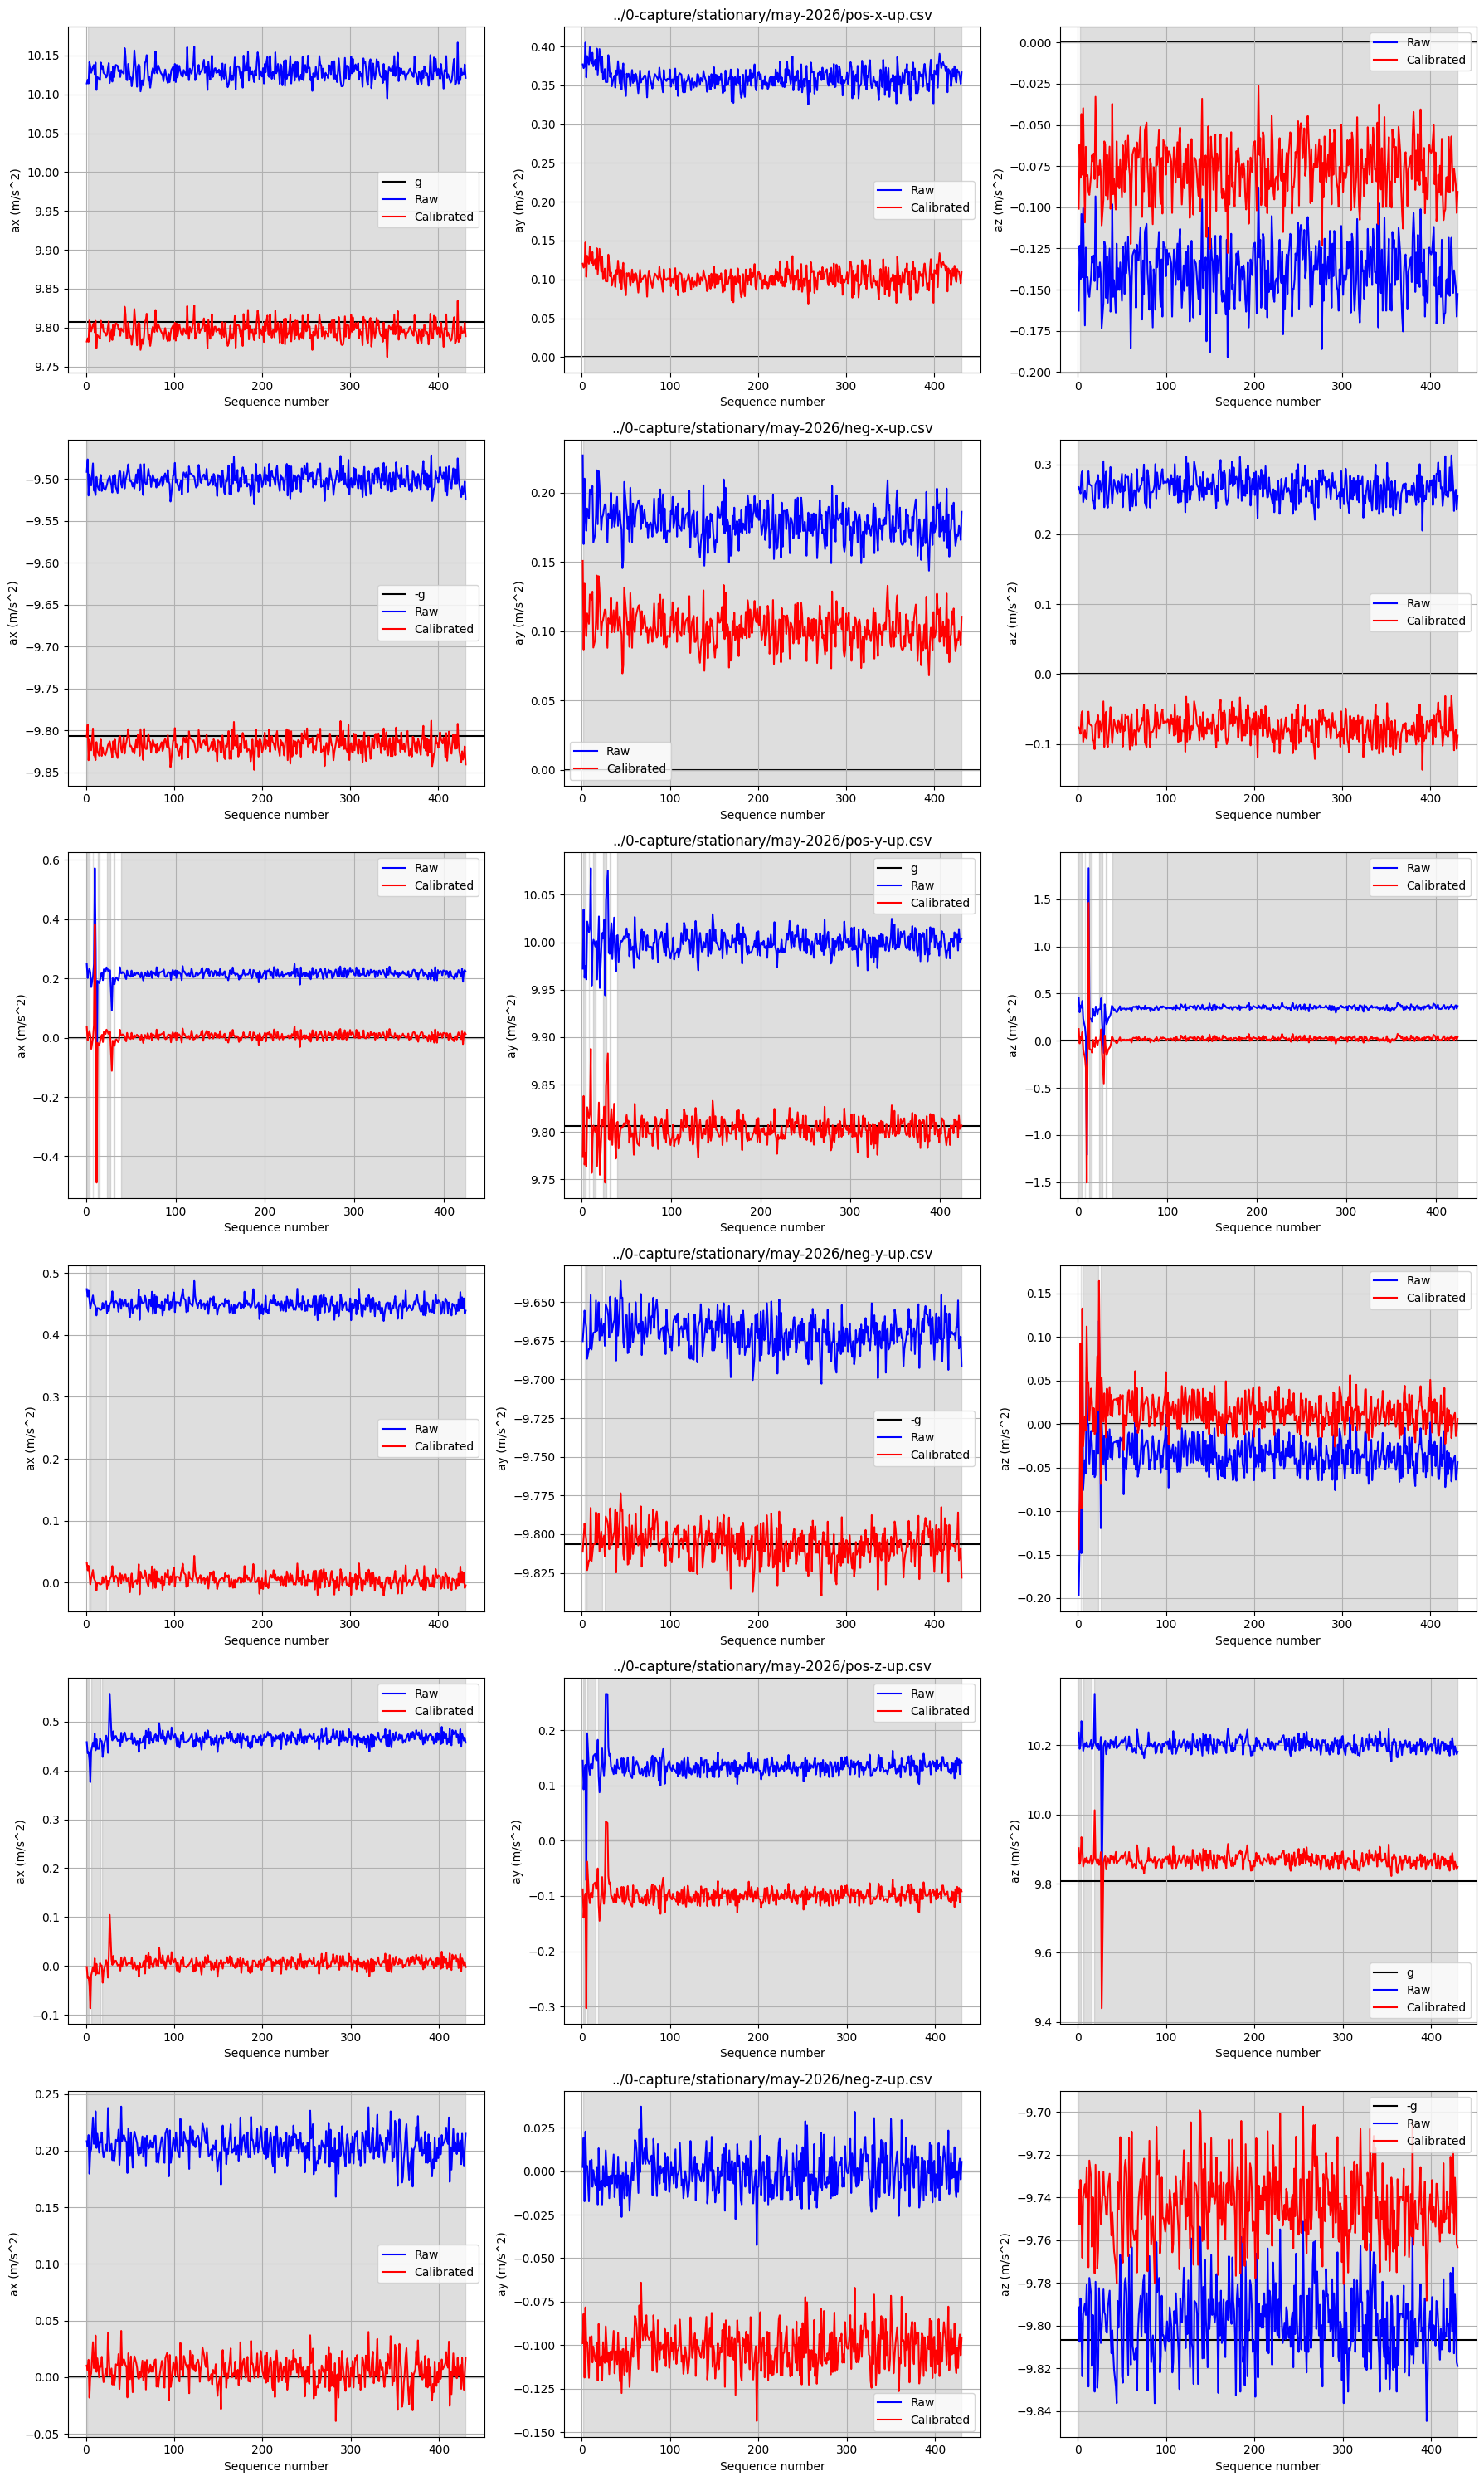

In [55]:
plotRawAndCalibratedAccelSeries(stationaryCaptures)

### Graphical inspection: simple rotations captures

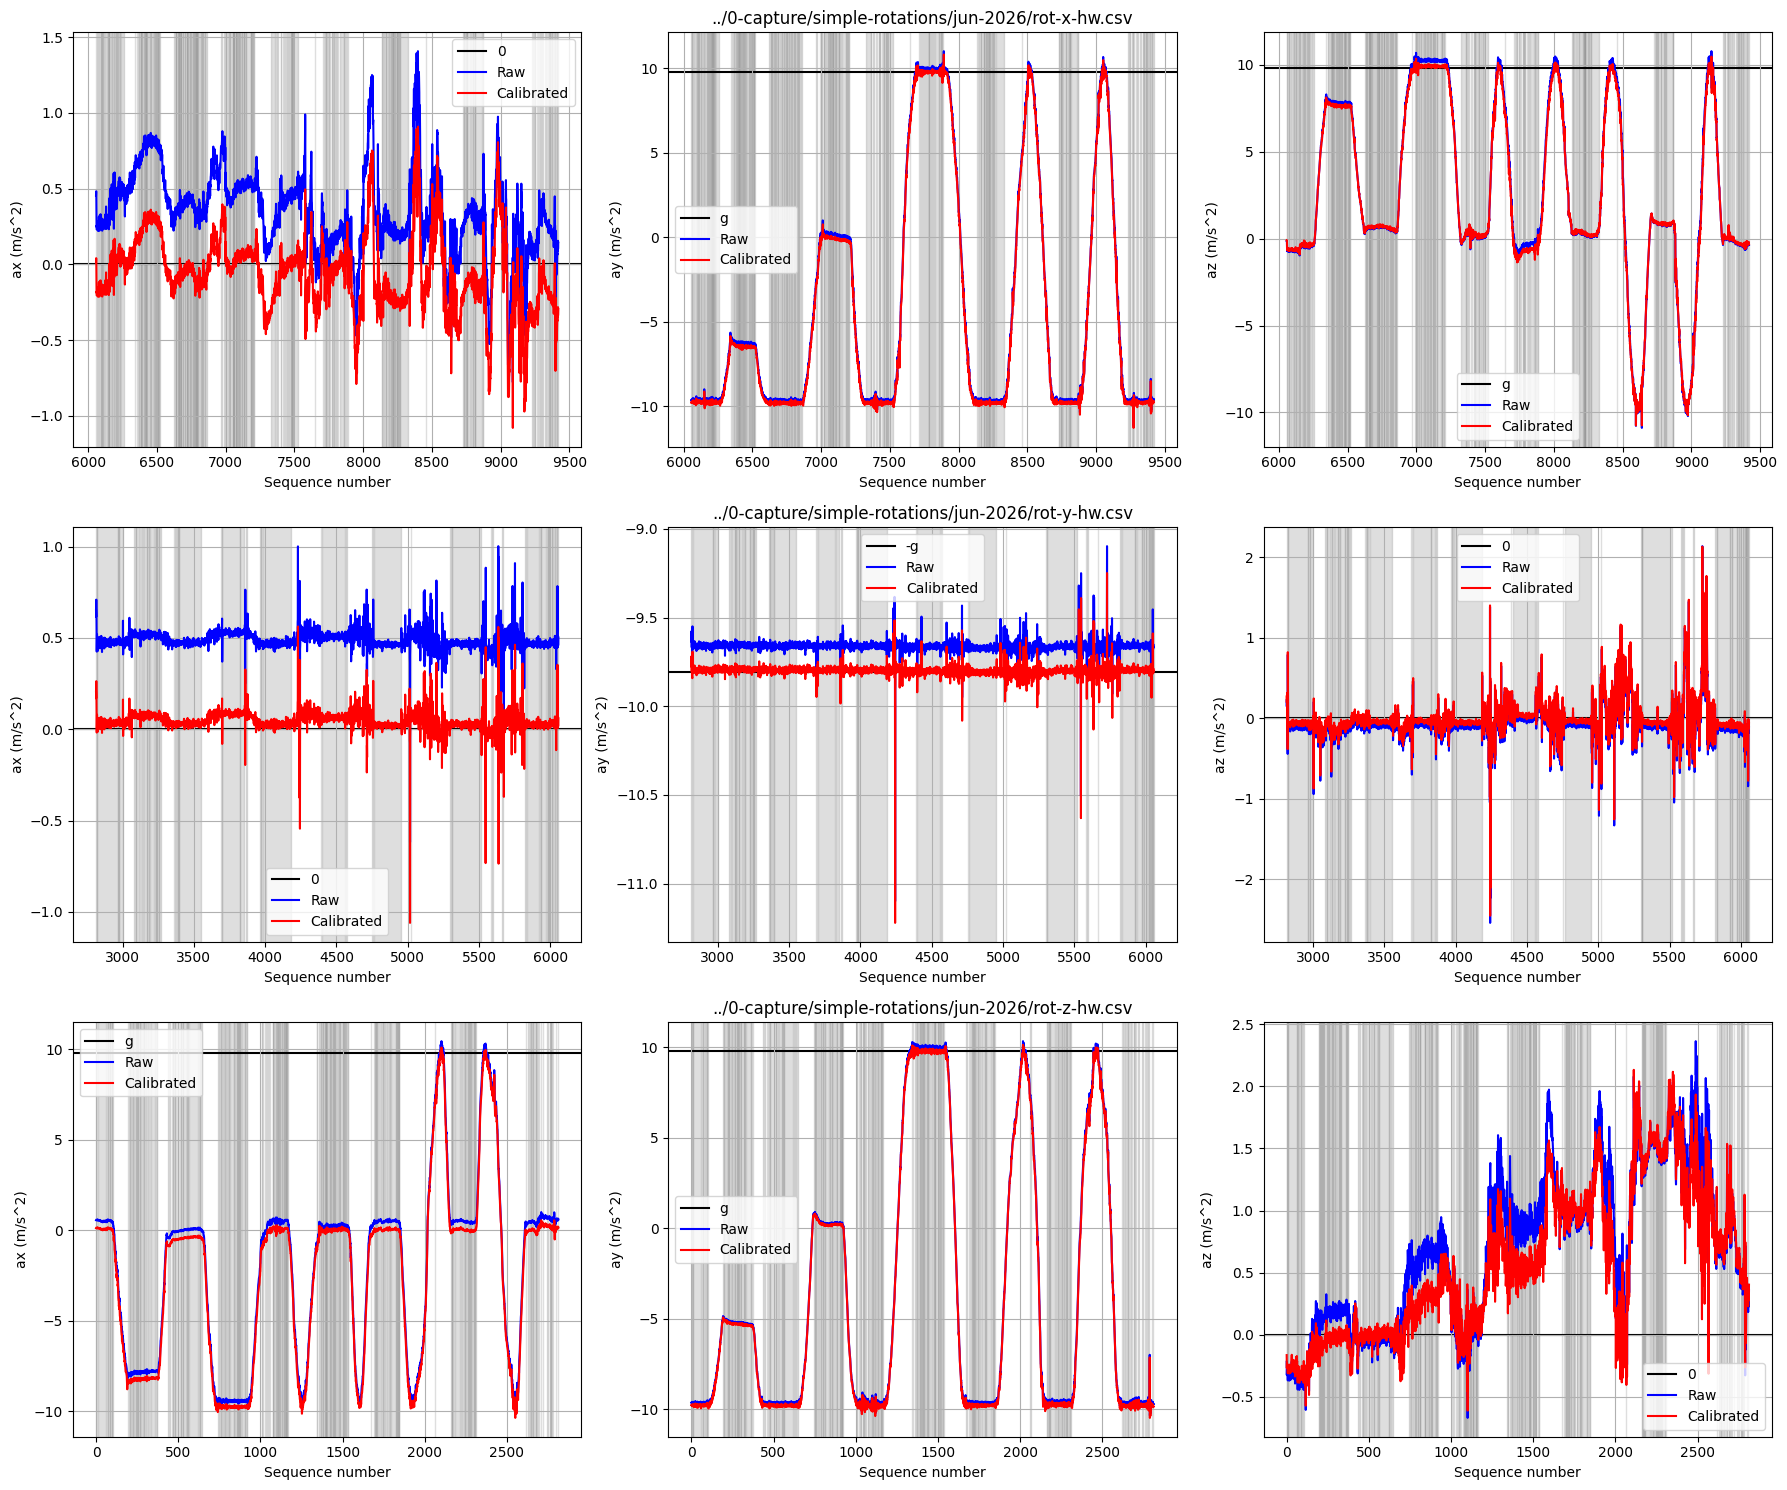

In [31]:
plotRawAndCalibratedAccelSeries(simpleRotationsCaptures)

## Gyroscope

For the gyroscope, I originally decided to just substract the stationary bias, but this may not be enough.
Now I'll update the stationary bias while the device is recording. Since gym exercises are mostly periodic, pauses between reps (i.e. stationary periods) can be used to update the bias with the following formula: 



$$
\mathbf{b}_{\omega,i} =
\begin{cases}
\alpha \mathbf{b}_{\omega,i-1} + (1-\alpha)\mathbf{\omega}_{i}, & \text{if stationary} \\
\mathbf{b}_{\omega,i-1}, & \text{otherwise}
\end{cases}
$$

Where $\mathbf{b}_{\omega,0}$ is the initial bias computed from the stationary captures. Then use:

$$
\mathbf{\omega}_{corr,i} = \mathbf{\omega}_{i} - \mathbf{b}_{\omega,i}
$$

where $\alpha$ is a smoothing factor close to $1$, so adaptation is slow and stable. 

Remembering my control theory lectures, during stationary periods, this calibration approach resembles a low-pass first order system. On continuous time, the solution for one axis, a step input with amplitude $\omega$ and initial bias $b_{0}$ would be:

$$
b(t) = e^{-t/\tau} b_{0} + (1 - e^{-t/\tau}) \cdot \omega
$$
Now discretize. Let $t = i \Delta t$, where $\Delta t = \frac{1}{f_s}$:

$$
b_{i} = e^{-\Delta t/\tau} b_{i-1} + (1 - e^{-\Delta t/\tau}) \cdot \omega_{i}
$$

Finally,
$$
\alpha \approx e^{-\Delta t/\tau}
$$
Notice that the relationship is only approximately true since $\omega$ is being subject to noise and imperfect stationarity detection. For this application, pauses between reps are brief, so $\tau$ should be approximately $1$ second. 

As an alternative, since I can't produce known angular velocities for a more sophisticated calibration right now, craft another device with my Arduino Uno, a stepper motor and some 3D-printed parts to make a rotating platform. It's relatively feasible but much more work.

Sources: 
* [Response of first order dynamic systems - Control theory - UTN FRSF](../../docs/misc/5-RespuestaDeSDsDeOrden1-TeoríaDeControl.pdf)

In [22]:
rollStationaryBias = np.mean(np.concatenate([w[:, 0] for (_, _, w) in rawOrientations]))
pitchStationaryBias = np.mean(
    np.concatenate([w[:, 1] for (_, _, w) in rawOrientations])
)
yawStationaryBias = np.mean(np.concatenate([w[:, 2] for (_, _, w) in rawOrientations]))
wStationaryBias = np.array([rollStationaryBias, pitchStationaryBias, yawStationaryBias])
print(f"\nwStationaryBias = {wStationaryBias}")


def calibrateGyroOffline(a, w):
    return w - wStationaryBias


SAMPLING_RATE = 30  # Hz
TIME_CONSTANT = 1.0  # seconds
ALPHA = np.exp(-1 / (SAMPLING_RATE * TIME_CONSTANT))
print(f"\nalpha = {ALPHA}")


def calibrateGyroOnline(a, w):
    wBias = np.zeros((len(w), 3))
    wBias[0, :] = wStationaryBias
    stationaryFlags = stationaryChecker.areStationarySamples(a, w)
    for i in range(1, len(w)):
        isStationary = stationaryFlags[i]
        if isStationary:
            wBias[i, :] = ALPHA * wBias[i - 1, :] + (1 - ALPHA) * w[i, :]
        else:
            wBias[i, :] = wBias[i - 1, :]
    return w - wBias


def plotRawAndCalibratedGyroSeries(captures):
    rows = len(captures)
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

    for i, capture in enumerate(captures):
        seq, a, w = reader.readRaw(capture)
        wCalibratedOffline = calibrateGyroOffline(a, w)
        wCalibratedOnline = calibrateGyroOnline(a, w)
        stationaryPeriods = stationaryChecker.findStationaryIntervals(seq, a, w)

        axes[i, 1].set_title(capture)
        for j in range(3):
            for lower, upper in stationaryPeriods:
                axes[i, j].axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)

            axes[i, j].plot(seq, w[:, j], label="Raw", color="blue")
            axes[i, j].plot(
                seq,
                wCalibratedOffline[:, j],
                label="Calibrated Offline",
                color="green",
            )
            axes[i, j].plot(
                seq,
                wCalibratedOnline[:, j],
                label="Calibrated Offline + Online",
                color="red",
            )
            axes[i, j].set_xlabel("Sequence number")
            axes[i, j].set_ylabel(f"{['wRoll', 'wPitch', 'wYaw'][j]} (deg/s)")
            axes[i, j].legend()
            axes[i, j].grid()
    fig.tight_layout()
    plt.show()


wStationaryBias = [-5.133702   3.22657   -1.3970467]

alpha = 0.9672161004820059


### Graphical inspection: stationary captures

Both the offline and offline + online calibration methods DO work, as the raw gyroscope samples are significantly biased and they get corrected. They visually perform very similarly when the device is completely still.

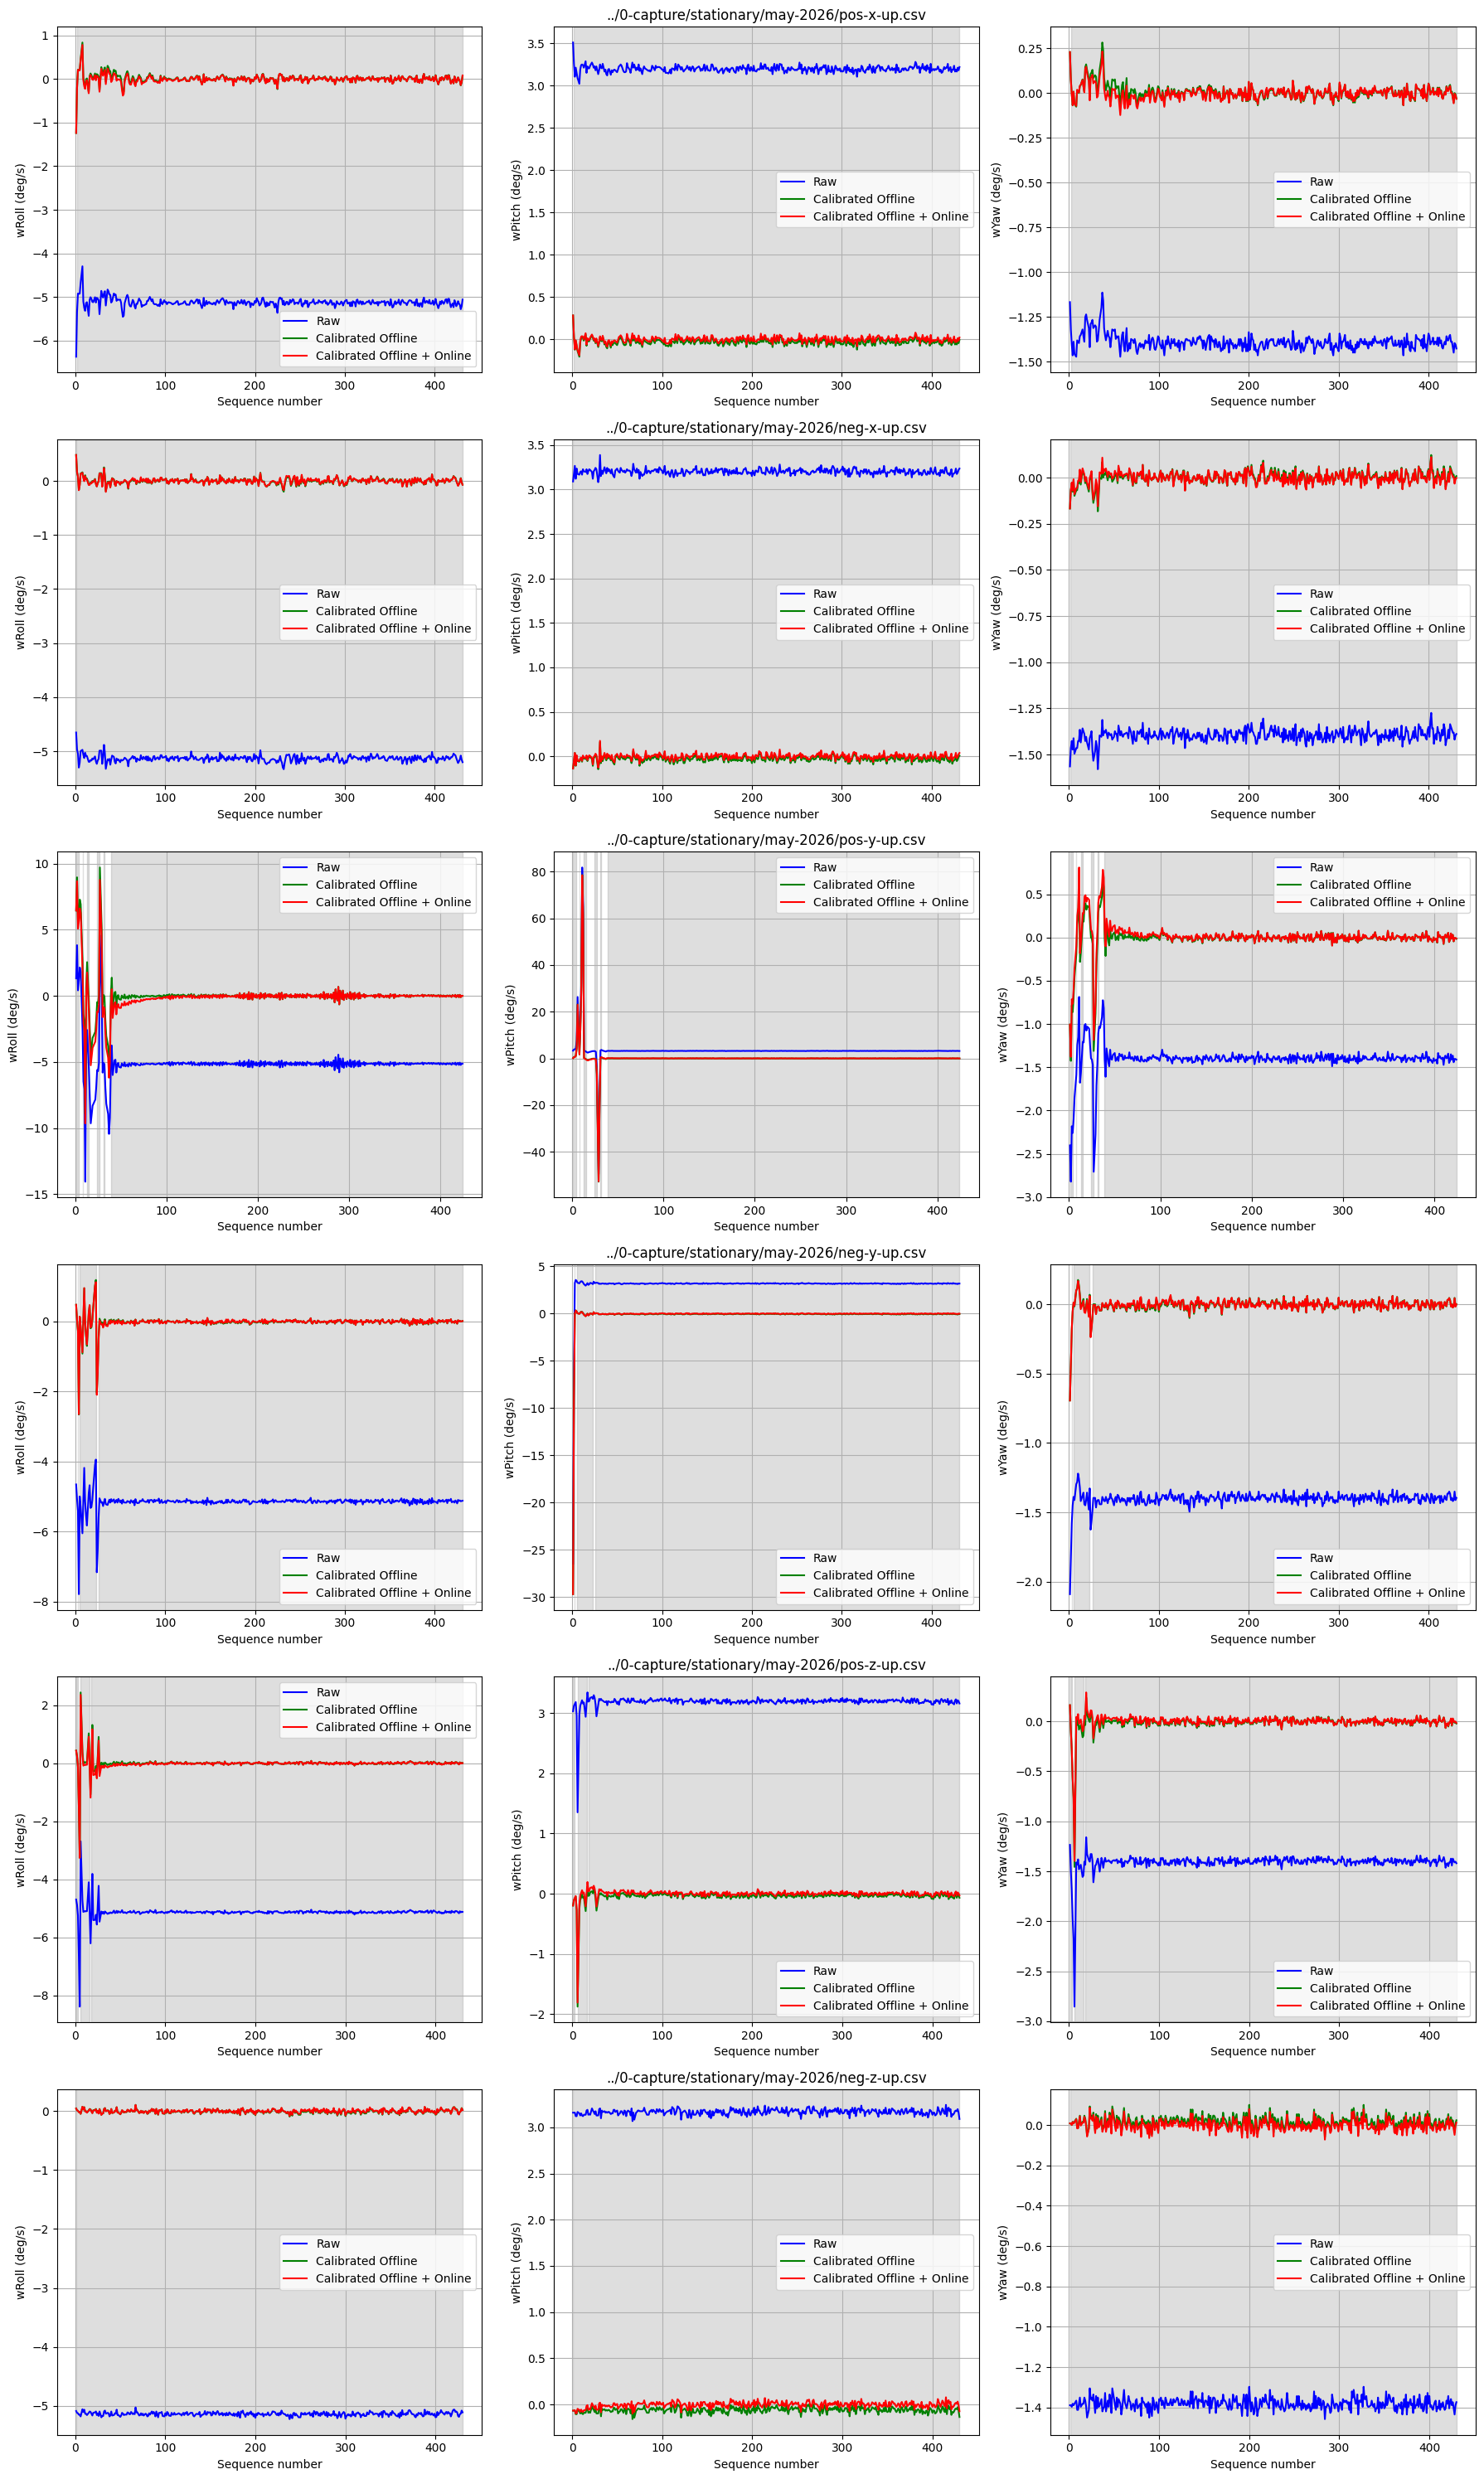

In [23]:
plotRawAndCalibratedGyroSeries(stationaryCaptures)

### Graphical inspection: simple rotations

Both methods also visually work similarly here. I can't judge the moving periods that much as the angular velocity produced by my hands when recording was done is unknown. Further inspection through metrics is needed.

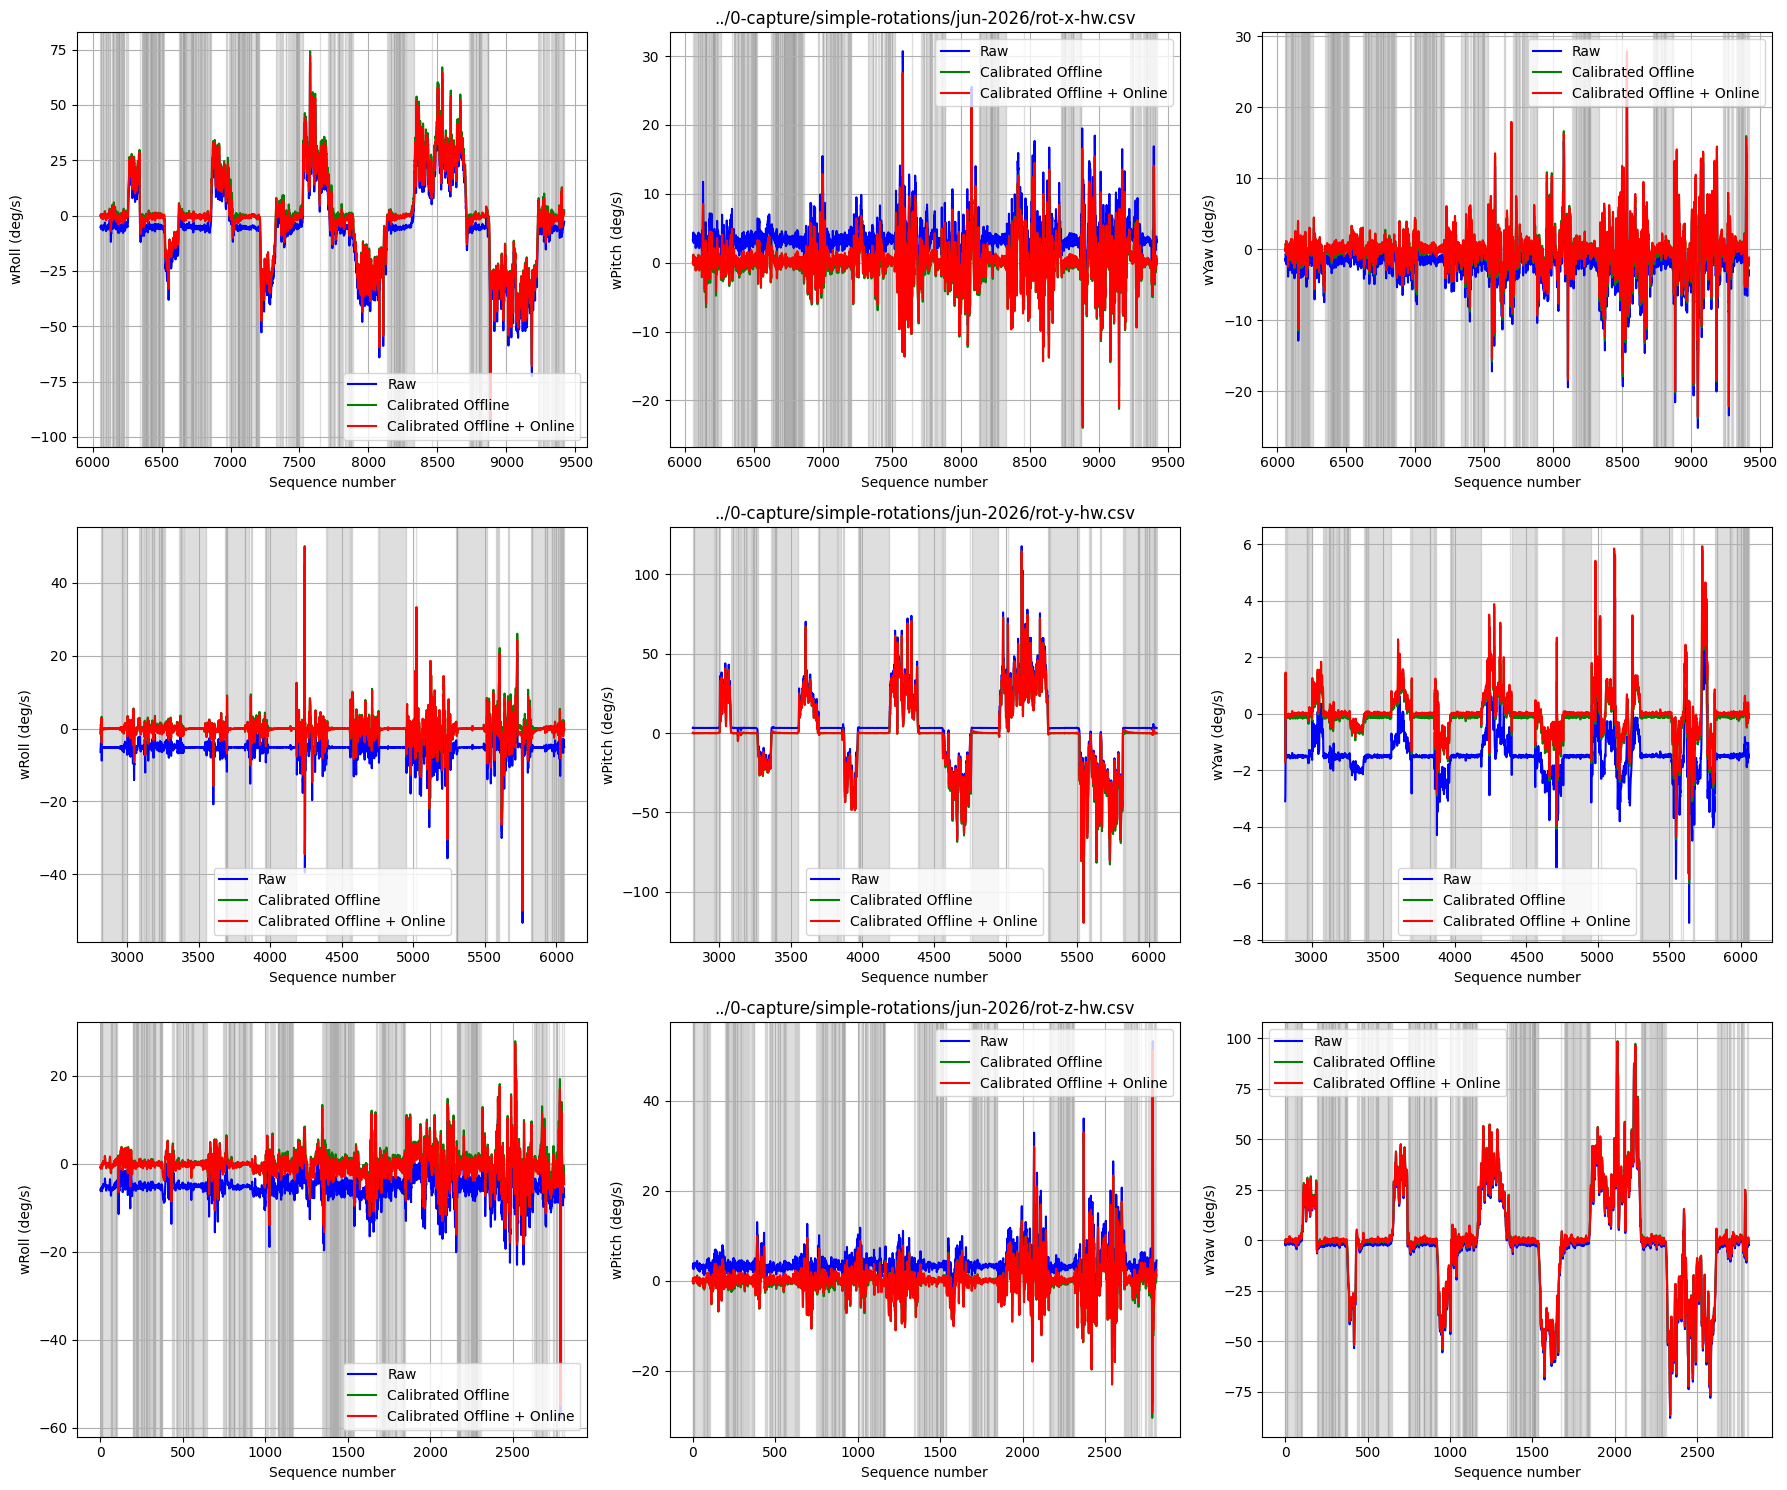

In [24]:
plotRawAndCalibratedGyroSeries(simpleRotationsCaptures)

### Numerical inspection: offline and offline + online calibration

During stationary periods, the following angular velocity metrics can be computed for each axis:
* Mean: should stay as close to zero as possible, which means better bias removal.
* Standard deviation: should be as low as possible, which means better noise removal.
* RMS: should be as low as possible, which means lower total stationary error.

The offline + online calibration performs significantly better (about one order of magnitude) on bias removal and slightly better on the standard deviation and RMS. This is consistent with the graphical inspection.

In [25]:
def computeGyroCalibrationMetrics(captures):
    axes = ["wRoll", "wPitch", "wYaw"]
    for i, capture in enumerate(captures):
        _, a, w = reader.readRaw(capture)
        stationaryFlags = stationaryChecker.areStationarySamples(a, w)
        wCalibratedOfflineStationary = np.array(
            [
                wCalOffline
                for i, wCalOffline in enumerate(calibrateGyroOffline(a, w))
                if stationaryFlags[i]
            ]
        )
        wCalibratedOnlineStationary = np.array(
            [
                wCalOnline
                for i, wCalOnline in enumerate(calibrateGyroOnline(a, w))
                if stationaryFlags[i]
            ]
        )

        print(f"{capture}:")
        for j, axisName in enumerate(axes):
            offlineAxis = wCalibratedOfflineStationary[:, j]
            onlineAxis = wCalibratedOnlineStationary[:, j]

            offlineAxisMean = np.mean(offlineAxis)
            onlineAxisMean = np.mean(onlineAxis)
            print(f"\t{axisName}:")
            print(
                f"\t\tmean: offline={offlineAxisMean:.4f}, "
                f"online={onlineAxisMean:.4f},",
                f"diff={offlineAxisMean - onlineAxisMean:.4f}",
                f"ratio={offlineAxisMean / onlineAxisMean:.4f}",
            )

            offlineAxisStd = np.std(offlineAxis)
            onlineAxisStd = np.std(onlineAxis)
            print(
                f"\t\tstd:  offline={offlineAxisStd:.4f}, "
                f"online={onlineAxisStd:.4f}, "
                f"diff={offlineAxisStd - onlineAxisStd:.4f}, "
                f"ratio={offlineAxisStd / onlineAxisStd:.4f}"
            )

            offlineAxisRMS = np.sqrt(np.mean(offlineAxis**2))
            onlineAxisRMS = np.sqrt(np.mean(onlineAxis**2))
            print(
                f"\t\tRMS:  offline={offlineAxisRMS:.4f}, "
                f"online={onlineAxisRMS:.4f}, "
                f"diff={offlineAxisRMS - onlineAxisRMS:.4f}, "
                f"ratio={offlineAxisRMS / onlineAxisRMS:.4f}"
            )


print("Gyroscope calibration metrics for stationary captures:")
computeGyroCalibrationMetrics(stationaryCaptures)
print("\nGyroscope calibration metrics for simple rotations captures:")
computeGyroCalibrationMetrics(simpleRotationsCaptures)

Gyroscope calibration metrics for stationary captures:
../0-capture/stationary/may-2026/pos-x-up.csv:
	wRoll:
		mean: offline=0.0107, online=-0.0005, diff=0.0112 ratio=-21.5036
		std:  offline=0.0886, online=0.0852, diff=0.0034, ratio=1.0401
		RMS:  offline=0.0893, online=0.0852, diff=0.0041, ratio=1.0477
	wPitch:
		mean: offline=-0.0294, online=-0.0021, diff=-0.0274 ratio=14.2607
		std:  offline=0.0329, online=0.0326, diff=0.0003, ratio=1.0088
		RMS:  offline=0.0441, online=0.0327, diff=0.0115, ratio=1.3502
	wYaw:
		mean: offline=0.0058, online=0.0002, diff=0.0057 ratio=34.5688
		std:  offline=0.0402, online=0.0368, diff=0.0033, ratio=1.0909
		RMS:  offline=0.0406, online=0.0368, diff=0.0038, ratio=1.1023
../0-capture/stationary/may-2026/neg-x-up.csv:
	wRoll:
		mean: offline=-0.0008, online=0.0013, diff=-0.0020 ratio=-0.6112
		std:  offline=0.0579, online=0.0565, diff=0.0014, ratio=1.0251
		RMS:  offline=0.0579, online=0.0565, diff=0.0014, ratio=1.0249
	wPitch:
		mean: offline=-0.0262

## Export results

In [26]:
def exportResults(captures):
    for capture in captures:
        seq, a, w = reader.readRaw(capture)
        aCalibrated = calibrateAccel(a)
        wCalibratedOffline = calibrateGyroOffline(a, w)
        wCalibratedOnline = calibrateGyroOnline(a, w)

        oldFileName = capture.split("/")[-1].split(".")[0]
        writer.writeRaw(
            f"./output/{oldFileName}-calib-affine-a-offline-w.csv",
            seq,
            aCalibrated,
            wCalibratedOffline,
        )
        writer.writeRaw(
            f"./output/{oldFileName}-calib-affine-a-online-w.csv",
            seq,
            aCalibrated,
            wCalibratedOnline,
        )


exportResults(stationaryCaptures)
exportResults(simpleRotationsCaptures)
exportResults(realExerciseCaptures)